# 4. Modelado supervisado

## 4.1 Objetivo
El objetivo de esta etapa es desarrollar y comparar distintos modelos de Machine Learning para predecir la popularidad de las canciones. Cada modelo se evalúa mediante validación cruzada utilizando métricas de regresión, con el propósito de seleccionar la alternativa con mejor capacidad predictiva.

## 4.2 Carga del conjunto de datos

In [4]:
from pathlib import Path
import sys

project_root = Path.cwd().parent
sys.path.append(str(project_root))

In [5]:
import numpy as np
import keras
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from keras.wrappers import SKLearnRegressor
from sklearn.neural_network import MLPRegressor
from src.modeling import build_pipeline, evaluate_models, create_deep_learning_model, train_and_evaluate
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import matplotlib.pyplot as plt

In [6]:
import pandas as pd

df = pd.read_csv("../data/processed/spotify_clean.csv")

In [7]:
df.head()

,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


## 4.3 Separación de variables

In [8]:
X = df.drop(columns=["popularity", "track_genre"])
y = df["popularity"]

In [9]:
categorical_features = ["explicit", "key", "mode", "time_signature"]
numerical_features = ["duration_ms", "danceability", "energy", "loudness", "speechiness", "acousticness", "instrumentalness", "liveness", "valence", "tempo"]
df[categorical_features] = df[categorical_features].astype("category")

In [10]:
preprocessor = ColumnTransformer(
        transformers= [
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
            ("num", StandardScaler(), numerical_features)
        ]
    )

## 4.4 División en entrenamiento y prueba

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(91200, 14)
(22800, 14)
(91200,)
(22800,)


## 4.5 Entrenamiento de modelos

En esta etapa se construyen y entrenan distintos modelos de regresión con el propósito de comparar su capacidad predictiva. Todos los modelos utilizan el mismo esquema de preprocesamiento, garantizando que la comparación se realice bajo las mismas condiciones.

In [13]:
deep_learning_model = SKLearnRegressor(
    model=create_deep_learning_model,
    fit_kwargs={
        "epochs": 50,
        "batch_size": 32,
        "verbose": 0
    }
)

models = {
    "Linear Regression": build_pipeline(
        LinearRegression(),
        preprocessor
    ),
    "Ridge": build_pipeline(
        Ridge(),
        preprocessor
    ),
    "Lasso": build_pipeline(
        Lasso(),
        preprocessor
    ),
    "ElasticNet": build_pipeline(
        ElasticNet(
            alpha=1.0,
            l1_ratio=0.5,
        ),
        preprocessor
    ),
    "Decision_Tree": build_pipeline(
        DecisionTreeRegressor(),
        preprocessor
    ),
    "Random_Forest": build_pipeline(
        RandomForestRegressor(
            n_estimators=100,
            n_jobs=-1
        ),
        preprocessor
    ),
    "Gradient_Boosting": build_pipeline(
        GradientBoostingRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=4
        ),
        preprocessor
    ),
    "MLPRegressor": build_pipeline(
        MLPRegressor(
            hidden_layer_sizes=(100,),
            activation="relu",
            solver="adam",
            max_iter=500
        ),
        preprocessor
    ),
    "Deep_Learning": build_pipeline(
        deep_learning_model,
        preprocessor
    )

}


In [14]:
resultados = pd.DataFrame(evaluate_models(models, X_train, y_train, 5))

g:\My Drive\Spotify-songs\venv-tf\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
g:\My Drive\Spotify-songs\venv-tf\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
g:\My Drive\Spotify-songs\venv-tf\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
g:\My Drive\Spotify-songs\venv-tf\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


2280/2280 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 486.1332 - mae: 18.1323
570/570 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
2280/2280 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 484.5644 - mae: 18.0913
570/570 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step  
2280/2280 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 482.7810 - mae: 18.0723
570/570 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step  
2280/2280 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 485.6423 - mae: 18.1191
570/570 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
2280/2280 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 488.6801 - mae: 18.1697
570/570 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


## 4.6 Comparación de modelos

La comparación mediante validación cruzada muestra diferencias claras en el desempeño de los modelos evaluados. Los modelos lineales (Regresión Lineal, Ridge, Lasso y ElasticNet) obtienen los valores más bajos de R^2, por lo que explican una proporción reducida de la variabilidad de la popularidad.

Por otro lado, los modelos basados en árboles presentan un mejor desempeño, destacando Random Forest, que obtiene el menor MAE y RMSE, así como el mayor valor de R^2. Esto indica que es el modelo que explica una mayor proporción de la variabilidad de la popularidad entre los modelos evaluados.

In [15]:
resultados

,Linear Regression,Ridge,Lasso,ElasticNet,Decision_Tree,Random_Forest,Gradient_Boosting,MLPRegressor,Deep_Learning
mae_mean,18.363980,18.363989,18.765384,18.713954,14.047609,11.305872,17.032393,16.837262,17.624342
mae_std,0.053315,0.053324,0.079276,0.077185,0.138288,0.093363,0.060623,0.094755,0.062811
rmse_mean,22.018837,22.018836,22.220461,22.186913,21.641832,15.688809,20.812986,20.769612,21.489430
rmse_std,0.053015,0.053020,0.071876,0.070806,0.177970,0.116718,0.062693,0.091541,0.057992
r2_mean,0.027382,0.027382,0.009496,0.012485,0.060278,0.506191,0.130998,0.134607,0.073586
r2_std,0.002667,0.002667,0.000423,0.000407,0.018753,0.007361,0.002010,0.006051,0.003929


## 4.7 Selección del mejor modelo

Random Forest fue seleccionado como modelo final al tener mejor desempeño durante la validación cruzada. A continuación se evalúa su desempeño sobre el conjunto de prueba y se analizan sus principales características.

In [16]:
random_forest_pipeline = build_pipeline(
        RandomForestRegressor(
            n_estimators=100,
            n_jobs=-1
        ),
        preprocessor)
final_results = train_and_evaluate(
    pipeline= random_forest_pipeline,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test
)

final_results

{'mae': 10.528228670434112,
 'rmse': 14.83359312327191,
 'r2': 0.5541154854940687}

El modelo tiene un desempeño consistente sobre el conjunto de prueba, alcanzando un R^2 cercano al obtenido en la validación cruzada.

In [17]:
# Hacemos las predicciones
y_pred = random_forest_pipeline.predict(X_test)

In [18]:
# Guardamos el modelo
import joblib

model_path = project_root / "models" / "random_forest_pipeline.joblib"
model_path.parent.mkdir(parents=True, exist_ok=True)

joblib.dump(random_forest_pipeline, model_path)

['g:\\My Drive\\Spotify-songs\\models\\random_forest_pipeline.joblib']

### Valores reales vs. predichos

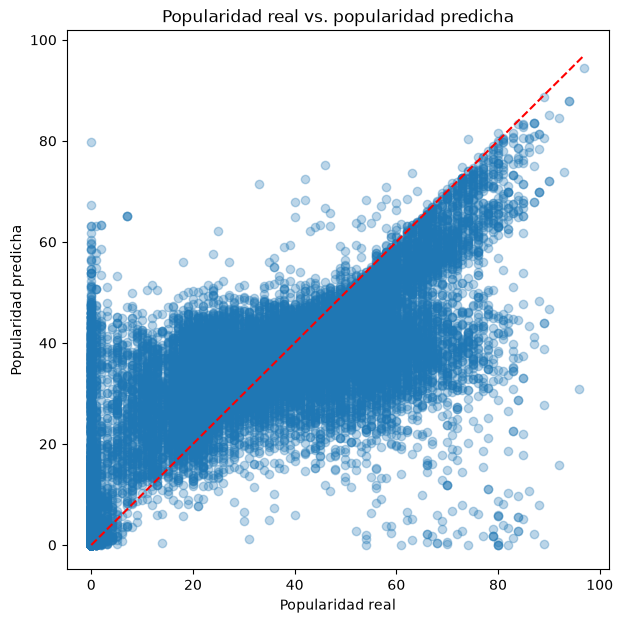

In [19]:
plt.figure(figsize=(7,7))
plt.scatter(y_test, y_pred, alpha=0.3)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Popularidad real")
plt.ylabel("Popularidad predicha")
plt.title("Popularidad real vs. popularidad predicha")
plt.show()

 Las predicciones presentan una mayor concentración en valores intermedios de popularidad, mientras que las canciones con popularidad muy baja o muy alta muestran errores de predicción más elevados. Esto indica que el modelo captura la tendencia general de los datos, sin embargo presenta una menor precisión en los valores extremos de la variable objetivo.

### Distribución de los errores de predicción

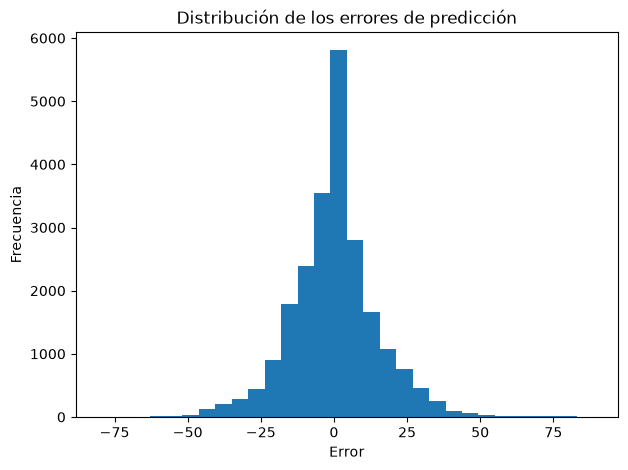

In [20]:
residuals = y_test - y_pred

plt.figure(figsize=(7,5))
plt.hist(residuals, bins=30)

plt.xlabel("Error")
plt.ylabel("Frecuencia")
plt.title("Distribución de los errores de predicción")
plt.show()

 Los residuos se concentran alrededor de cero, lo que indica que el modelo no tiende a sobreestimar o subestimar la popularidad de las canciones. También se observan algunos errores más grandes, lo que coincide con la dificultad para predecir canciones con valores extremos de popularidad.

### Importancia de las variables

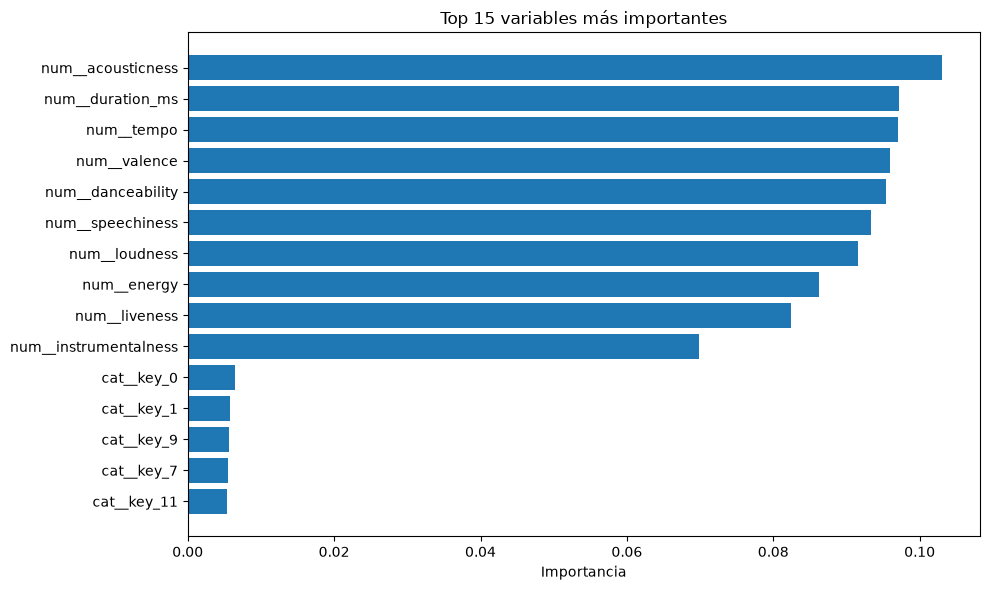

In [21]:
preprocessor = random_forest_pipeline.named_steps["preprocessor"]

feature_names = preprocessor.get_feature_names_out()

rf = random_forest_pipeline.named_steps["model"]

importances = rf.feature_importances_

importance_df = (
    pd.DataFrame({
        "Variable": feature_names,
        "Importancia": importances
    })
    .sort_values("Importancia", ascending=False)
)

top = importance_df.head(15)

plt.figure(figsize=(10,6))
plt.barh(top["Variable"], top["Importancia"])
plt.gca().invert_yaxis()

plt.title("Top 15 variables más importantes")
plt.xlabel("Importancia")
plt.tight_layout()

plt.show()

 Las variables con mayor importancia para el modelo son acousticness, duration_ms y tempo. Sin embargo, la importancia se encuentra distribuida entre varias características, lo que indica que la popularidad de una canción depende de la combinación de varios atributos y no de una sola variable.

## 4.8 Conclusiones

 Se comparó el desempeño de distintos modelos de regresión mediante validación cruzada para determinar el modelo con mejor capacidad predictiva. Random Forest fue seleccionado como modelo final al obtener los mejores resultados durante la evaluación. En el conjunto de prueba alcanzó un R^2 de 0.55, por lo que fue el modelo utilizado en el desarrollo de la aplicación interactiva presentada en la siguiente etapa del proyecto.

## 4.10 Exportación de resultados

Se guardan los principales resultados del modelado para utilizarlos posteriormente en la aplicación de Shiny.

In [ ]:
results_dir = project_root / "results"
resultados_export = (
    resultados
    .transpose()
    .reset_index()
    .rename(columns={"index": "modelo"})
)

resultados_export.to_csv(
    results_dir / "model_results.csv",
    index=False
)

final_metrics_df = pd.DataFrame({
    "metrica": ["MAE", "RMSE", "R2"],
    "valor": [
        final_results["mae"],
        final_results["rmse"],
        final_results["r2"]
    ]
})

final_metrics_df.to_csv(
    results_dir / "final_metrics.csv",
    index=False
)

predictions_df = pd.DataFrame({
    "popularidad_real": np.asarray(y_test),
    "popularidad_predicha": np.asarray(y_pred)
})

predictions_df["residuo"] = (
    predictions_df["popularidad_real"]
    - predictions_df["popularidad_predicha"]
)

predictions_df.to_csv(
    results_dir / "predictions.csv",
    index=False
)

importance_export = importance_df.copy()

importance_export["Variable"] = (
    importance_export["Variable"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

importance_export.to_csv(
    results_dir / "feature_importance.csv",
    index=False
)



: 